# Evaluation — llama3.3:70b · pdfplumber · whole-doc
**Samples evaluated:** 3–10 (samples 1 & 2 excluded — used for prompt development)

In [1]:
TAG     = "llama3.3-70b_pdfplumber_whole_doc"
EXCLUDE = [1, 2]

In [2]:
from dmpbridge.evaluation.evaluate import load_method, compute_f1_rows, confusion_matrix_df
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df, conf, errs = load_method(TAG, exclude=EXCLUDE)

tc, tn = int(df['correct'].sum()), int(df['total'].sum())
print(f'Tag     : {TAG}')
print(f'Samples : {df["sample"].tolist()}  (1 & 2 excluded)')
print(f'Overall : {tc}/{tn}  ({tc/tn*100:.1f}% block accuracy)')

Tag     : llama3.3-70b_pdfplumber_whole_doc
Samples : ['sample3', 'sample4', 'sample5', 'sample6', 'sample7', 'sample8', 'sample9', 'sample10']  (1 & 2 excluded)
Overall : 403/488  (82.6% block accuracy)


## F1 Score per Label

Label                    Precision    Recall        F1   Support
--------------------------------------------------------------
title                       100.0%     88.9%     94.1%         9
section.title                73.7%     84.8%     78.9%        33
section.description          23.5%    100.0%     38.1%        20
question.text                 0.0%      0.0%      0.0%         0
answer.text                 100.0%     81.5%     89.8%       426
--------------------------------------------------------------


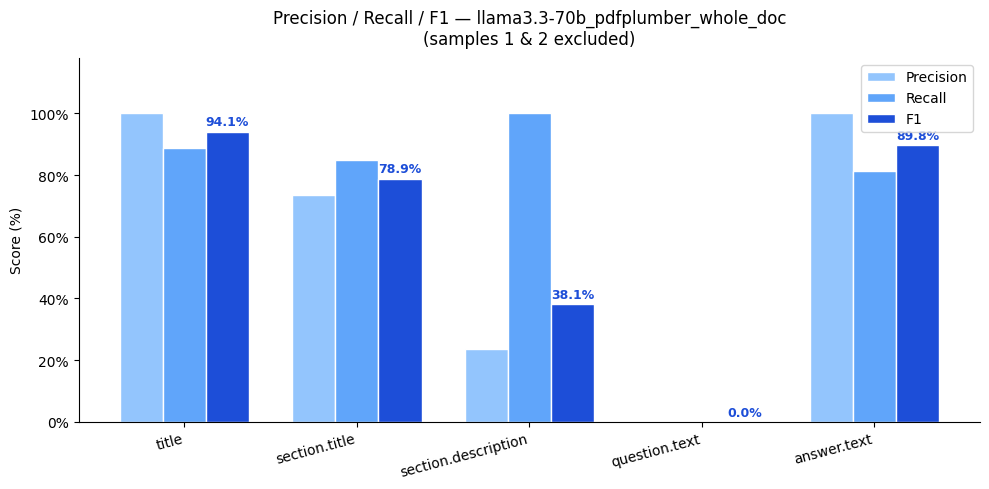

In [3]:
df_f1 = compute_f1_rows(conf)

print(f"{'Label':<22}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'Support':>8}")
print("-" * 62)
for row in df_f1.itertuples():
    print(f'{row.label:<22}  {row.precision*100:>9.1f}%  {row.recall*100:>7.1f}%  {row.f1*100:>7.1f}%  {row.support:>8}')
print("-" * 62)

fig, ax = plt.subplots(figsize=(10, 5))
labels = df_f1["label"].tolist()
xi, w  = range(len(labels)), 0.25

ax.bar([i - w for i in xi], df_f1["precision"]*100, width=w, label="Precision", color="#93c5fd", edgecolor="white")
ax.bar([i     for i in xi], df_f1["recall"]*100,    width=w, label="Recall",    color="#60a5fa", edgecolor="white")
f1_bars = ax.bar([i + w for i in xi], df_f1["f1"]*100, width=w, label="F1", color="#1d4ed8", edgecolor="white")

for bar, row in zip(f1_bars, df_f1.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{row.f1*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1d4ed8')

ax.set_xticks(list(xi))
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 118)
ax.set_ylabel('Score (%)')
ax.set_title(f'Precision / Recall / F1 — {TAG}\n(samples 1 & 2 excluded)', pad=10)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
sns.despine()
plt.tight_layout()
plt.show()

## Confusion Matrix
Rows = true label · Columns = predicted label

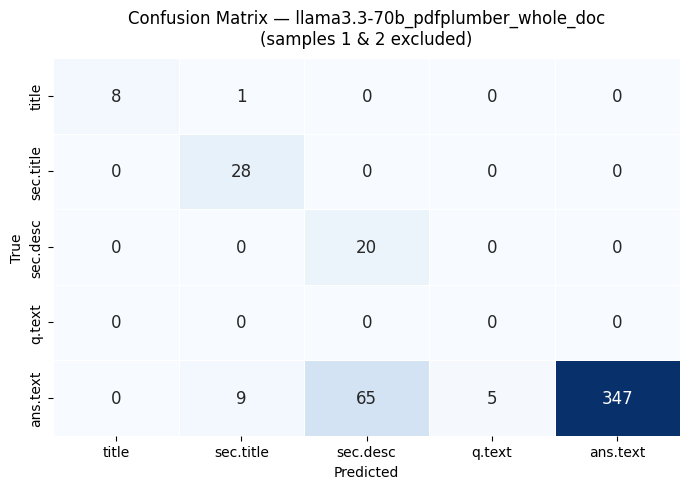

In [4]:
mat = confusion_matrix_df(conf).drop(columns=["missed"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(mat, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white",
            ax=ax, cbar=False, annot_kws={"size": 12})
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {TAG}\n(samples 1 & 2 excluded)", pad=10)
plt.tight_layout()
plt.show()